In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import itertools
from itertools import product

import cmocean
from glob import glob
import cartopy
from cartopy.crs import Geodetic, PlateCarree
import warnings

import pandas as pd
import geopandas as gpd

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
# Paths
project_folder_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/')
data_folder_path = project_folder_path / 'output/'
sample_points_file_path = data_folder_path / 'sample_points/sample_points_moved.geojson'
voronoi_polygons_file_path = data_folder_path / 'sample_points/voronoi_polygons_moved.geojson'
output_path = project_folder_path / 'Figures/connectivity_maps/'

In [3]:
# Load the sample points and the voronoi polygons
sample_points = gpd.read_file(sample_points_file_path)
sample_ids = sample_points.location_id
voronoi_polygons = gpd.read_file(voronoi_polygons_file_path)
connectivity_matrix = pd.read_csv(
	data_folder_path / 'connectivity_matrices/connectivity_matrix.csv',
	index_col=0,
	)

# Functions

In [5]:
# Set the basic mapping parameters
suptitle_size = 20
axis_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = PlateCarree()
def basemap(ax, extent=extent):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [ ]:
def define_cmap(
	cmap_input='coolwarm',
	cmdiscrete=False,
	value_min=None,value_max=None
	):
	if isinstance(cmap_input, str):
		cmap = mpl.colormaps.get_cmap(cmap_input)
	elif isinstance(cmap_input, type(cmocean.cm.haline)):
		cmap = cmap_input
	elif not isinstance(cmap_input, type(cmocean.cm.haline)):
		return print("Please input colormap or colormap name (str).")

	vmax = 10**np.ceil(np.log10(value_max))
	vmin = 10**np.floor(np.log10(value_min))
	sample_steps = vmax-vmin
	norm = colors.Normalize(vmin=value_min, vmax=value_max)
	# resample the colormap into the amount of discrete steps of difference 
	# between the vmin and vmax in power of 10
	difference_of_magnitude = (np.log10(vmax) - np.log10(vmin)).astype(int) 
	if (difference_of_magnitude >2):
		while difference_of_magnitude > 10:
			difference_of_magnitude=np.ceil(difference_of_magnitude/2).astype(int)
		sample_steps = difference_of_magnitude
		norm = LogNorm(vmin=vmin, vmax=vmax,)
	else:
		sample_steps = value_max-value_min
	if cmdiscrete:
		cmap = cmap.resampled(sample_steps)
		cmap.set_under(color="#00000000") # force the first color entry to be invisible
	return cmap, norm

# Maps

In [ ]:
north_sea_sample_ids = sample_ids.where(sample_points.sea == "northsea").dropna().tolist()
non_genetic_sample_ids = sample_ids.where(sample_points.genomic_data == False).dropna().tolist()

In [ ]:
def draw_voronoi_polygons(
	ax,
	cmap="rainbow", 
	edgecolor="black",
	facealpha=0.2,
	voronoi_polygons=voronoi_polygons
	):
	voronoi_polys = voronoi_polygons.copy()
	voronoi_polys.plot(ax=ax, alpha=facealpha, column="location_id", cmap=cmap)
	voronoi_polys.boundary.plot(ax=ax, color=edgecolor,)

In [8]:
marker_genetic = pd.DataFrame(
    data=np.array([["dodgerblue", "s"], ["green", "^"],]),
    index=[True, False], 
    columns=["color", "marker"],
)

marker_kind = pd.DataFrame(
    data=np.array([["darkred", "s",], ["dodgerblue", "^",], ["salmon", "s",]]),
    index=["real", "digital", "moved"], 
    columns=["color", "marker",],
)

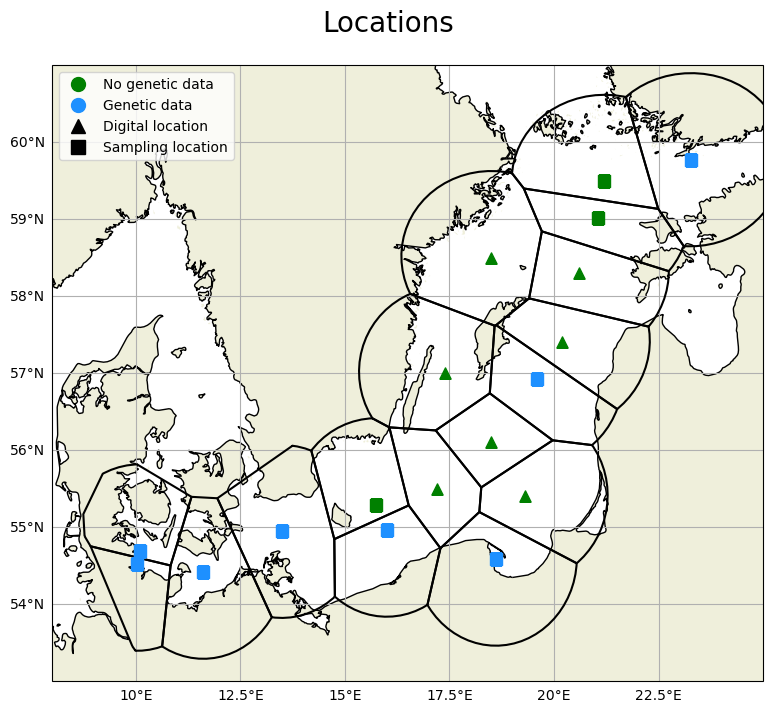

In [50]:
def draw_empty_map(
	sample_points=sample_points,
	voronoi_polygons=voronoi_polygons,
	show_polygons=True,
	only_baltic=False,
	extent=extent,
	ms=10,
	ls="None",
	file_name=None,
	):
	fig = plt.figure(figsize=mapsize)
	fig.suptitle("Locations", size=suptitle_size, y=0.95)
	ax_map = fig.add_subplot(projection=PlateCarree())
	if only_baltic:
		sample_points = sample_points[
			~sample_points['location_id_old'].isin(north_sea_sample_ids)
			]
		voronoi_polygons = voronoi_polygons[
			~voronoi_polygons['location_id_old'].isin(north_sea_sample_ids)
			]
		extent = (8, 25, 53, 61)
	basemap(ax_map, extent=extent)
	if show_polygons:
			draw_voronoi_polygons(
				ax_map, facealpha=0, 
				voronoi_polygons=voronoi_polygons,
				)
	map_points = sample_points[["geometry", "sample_kind", "genomic_data"]]
	for i, (geom, kind, genetic) in map_points.iterrows():
			lon, lat = geom.x, geom.y
			marker = marker_kind["marker"][kind]
			color = marker_genetic["color"][genetic]
			ax_map.scatter(lon, lat, marker=marker, color=color, zorder=5, label=kind, s=65)

	no_genetic = Line2D([], [], c="green", marker='o', ls=ls, ms=ms, label="No genetic data")
	genetic = Line2D([], [], c="dodgerblue", marker='o', ls=ls, ms=ms, label="Genetic data")
	digital = Line2D([], [], c="k", marker='^', ls=ls, ms=ms, label="Digital location")
	sample = Line2D([], [], c="k", marker='s', ls=ls, ms=ms, label="Sampling location")

	plt.legend(handles=[no_genetic, genetic, digital, sample])
	if file_name is not None:
		plt.savefig(Path(output_path, file_name), format="pdf")
	plt.show()
draw_empty_map(
	only_baltic=True,
	file_name='empty_map_baltic.pdf',
	)

## Connectivity Map

In [18]:
def read_cmap(cmap_input):
        if isinstance(cmap_input, str):
                return mpl.colormaps.get_cmap(cmap_input)
        elif isinstance(cmap_input, type(cmocean.cm.haline)):
                return cmap_input
        elif not isinstance(cmap_input, type(cmocean.cm.haline)):
                return print("Please input colormap or colormap name (str).")

In [19]:
def getXY(point):
    return (point.x.values[0], point.y.values[0])

In [20]:
def extent_to_rectangle(extent):
    x, y = extent[0], extent[2]
    width = extent[1] - extent[0]
    height = extent[3] - extent[2]
    return (x, y), width, height


In [21]:
def draw_self_connections(ax, matrix, norm, cmap=cmocean.cm.matter):
        sample_points = gpd.read_file(sample_points_file_path).to_crs(map_projection).set_index("location_id")
        sample_points = sample_points[sample_points["sample_kind"] != "digital"]
        max_connection = matrix.max(axis=None)

        self_connections = pd.DataFrame(
                data=[[index, matrix[index][index]] for index in matrix.index],
                columns=["location_id","self_connection"]
        ).set_index("location_id")
        sample_points = sample_points.join(self_connections)
        
        colors = [cmap(norm(self_connection),) for self_connection in sample_points.self_connection]
        sizes = [100 + (self_connection/max_connection)*500 for self_connection in sample_points.self_connection]
        sample_points.plot(ax=ax, color=colors, markersize=sizes, edgecolor="k",)

In [22]:
def draw_connections(ax, matrix, norm, cmap=cmocean.cm.haline,):
        sample_points = gpd.read_file(sample_points_file_path).to_crs(map_projection)
        for (incomming, outgoing) in product(matrix, repeat=2):
                n_connections = matrix[outgoing][incomming]
                if np.isnan(n_connections):
                        continue # abort if there are no connections
                extent = ax.get_extent()
                xy_outgoing = getXY(sample_points[sample_points.location_id == outgoing].geometry)
                xy_incomming = getXY(sample_points[sample_points.location_id == incomming].geometry)
                if not (extent[0] < xy_incomming[0] < extent[1]) or not extent[0] < xy_outgoing[0] < extent[1]:
                        continue  # abort if there are no connections within the extent
                color = cmap(norm(n_connections))
                con = ConnectionPatch(
                        xyA=xy_outgoing, xyB=xy_incomming, coordsA=ax.transData,
                        color=color, lw=2.2, zorder=5, edgecolor="k",
                        shrinkA=10, shrinkB=10,
                )
                con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
                con.set_connectionstyle("Arc3,rad=0.3")
                ax.add_artist(con)

In [26]:
def make_connectivitymap(
        matrix, 
        map_projection=map_projection, mapsize=mapsize, suptitle="connectivity Map",
        only_genetic=True, show_polygons=False, map_extent=None,
        cmap_scatter=cmocean.cm.matter, cmap = cmocean.cm.haline,
        filename=None,
        ):
        matrix = matrix.mask(matrix == 0)
        if only_genetic:
                matrix = matrix.drop(columns=non_genetic_sample_ids, index=non_genetic_sample_ids, errors="ignore")
        if not map_extent:
                map_extent=extent
        
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
        cmap = read_cmap(cmap)
        (cmap, norm) = define_cmap(cmap, cmdiscrete=True, value_min=min_connection, value_max=max_connection)
        
        fig = plt.figure(figsize=(14,10))
        # Main Map in top left
        ax_main = fig.add_axes([0.05, 0.4, 0.7, 0.55], projection=map_projection)
        if show_polygons:
                draw_voronoi_polygons(ax=ax_main, facealpha=0)
        basemap(ax_main, map_extent)
        draw_connections(ax_main, matrix, norm=norm, cmap=cmap)
        draw_self_connections(ax_main, matrix, norm=norm, cmap=cmap)
        
        # Zoom onto west baltic in bottom left
        ax_westbaltic = fig.add_axes([0.05, 0.05, 0.7, 0.3], projection=map_projection)
        basemap(ax_westbaltic)
        westbaltic_extent = [9.5,16.5,54,55.5,]
        ax_westbaltic.set_extent(westbaltic_extent, PlateCarree())
        draw_connections(ax_westbaltic, matrix, norm=norm, cmap=cmap)
        draw_self_connections(ax_westbaltic, matrix, norm=norm, cmap=cmap)

        cax_arrows = fig.add_axes([0.75, 0.05, 0.03, 0.9])
        fig.colorbar(ScalarMappable(norm, cmap), cax=cax_arrows, label="relative normalized connection")
        cax_arrows.minorticks_off()

        westbaltic_xy, westbaltic_width, westbaltic_height = extent_to_rectangle(westbaltic_extent)
        ax_main.add_patch(Rectangle(
                westbaltic_xy, westbaltic_width, westbaltic_height,
                fill=False, color='k', lw=1.5, zorder=100, transform=Geodetic(),
        ))

        if filename is not None:
                plt.savefig(Path(output_path, filename), format="pdf")
        plt.show()

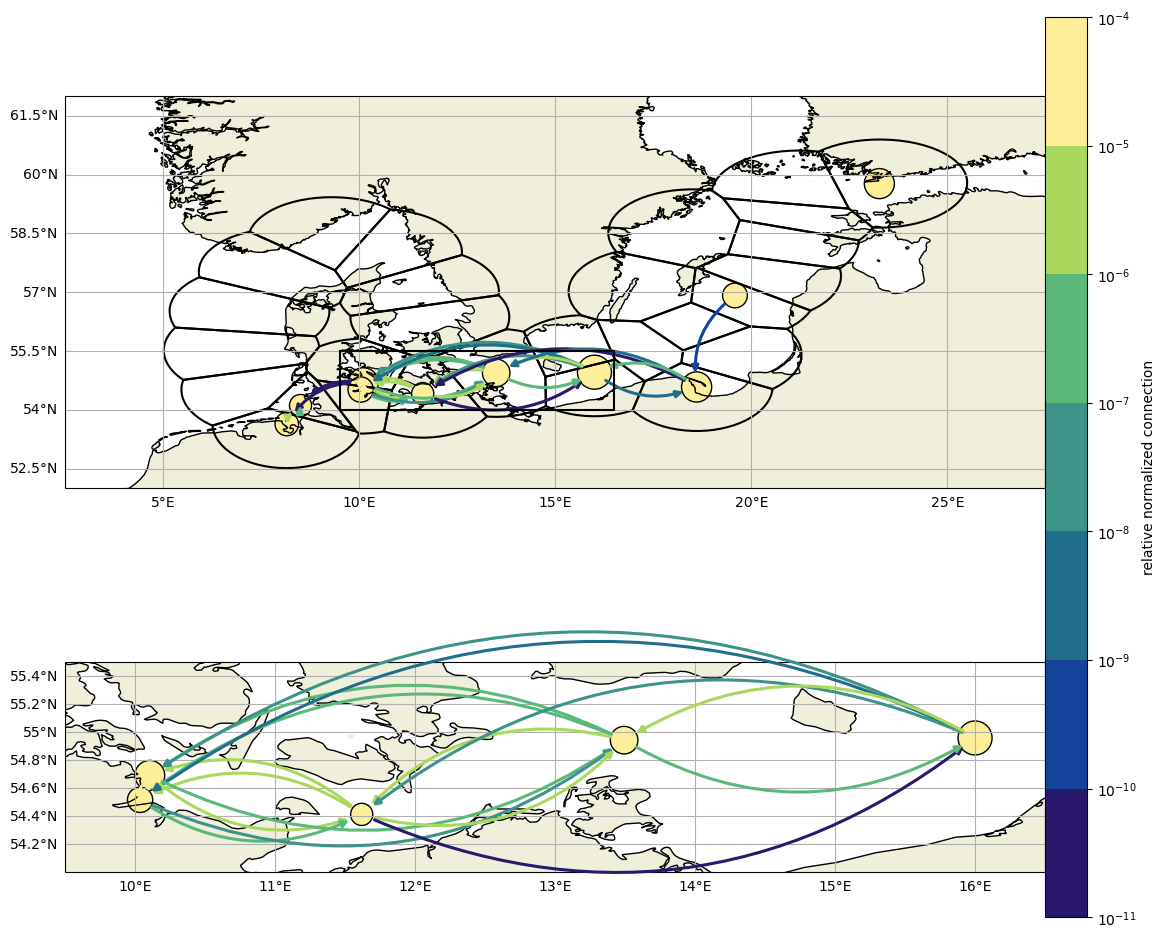

In [32]:
make_connectivitymap(
        matrix=connectivity_matrix, 
        show_polygons=True,
        # filename="connectivityMap_genetic.pdf"
)

In [28]:
make_connectivitymap(
        matrix=df_cmatrix_normalized_relative_baltic_genetic, only_genetic=True, map_extent=(8, 25, 53, 61),
        # filename="connectivityMap_baltic_genetic.pdf"
)

NameError: name 'df_cmatrix_normalized_relative_baltic_genetic' is not defined

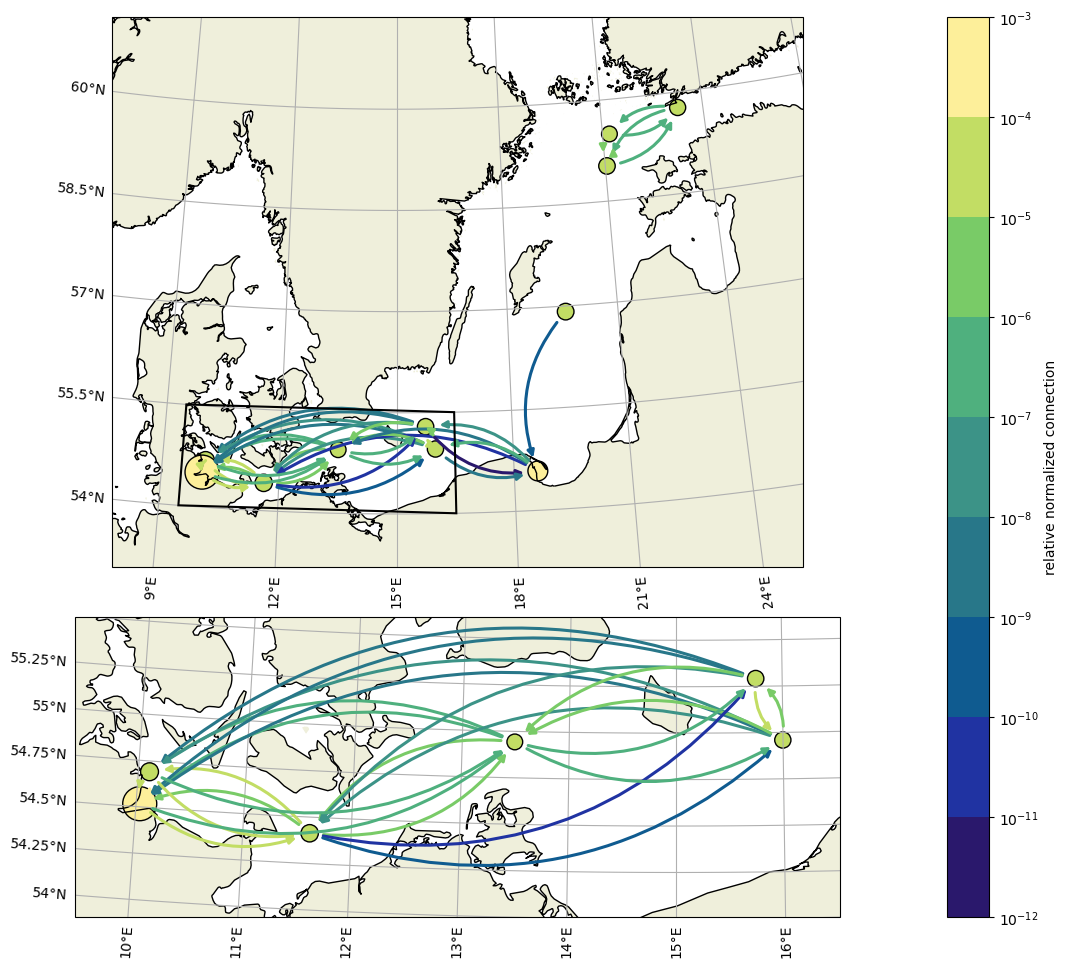

In [ ]:
make_connectivitymap(
        matrix=df_cmatrix_normalized_relative_baltic_sampled, only_genetic=False, map_extent=(8, 25, 53, 61),
        # filename="connectivityMap_baltic_sampled.pdf"
)